In [1]:
from cVAE import cVAE
from MDN import mdn, Mixture
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from tortreinador.utils.View import init_weights
from config import PlanetsDataGenerator, input_parameters, output_parameters, DEVICE, BASE_PATH, x_labels
import torch
import os
import joblib
import numpy as np
import pandas as pd
import corner
import math

plt.rcParams['axes.labelcolor'] = 'black'     # xlabel、ylabel
plt.rcParams['xtick.color']     = 'black'    # x 轴刻度文字
plt.rcParams['ytick.color']     = 'black'  # y 轴刻度文字
plt.rcParams['legend.edgecolor'] = 'white'  # 图例边框颜色
plt.rcParams['legend.facecolor'] = 'white'  # 图例背景色
plt.rcParams['text.color']      = 'black'    # 其他文本
plt.rcParams['axes.grid'] = False
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

x_max = [0.15, 1, 1, 0.1, 1, 1.5, 6, 1.5]

In [2]:
def calculate_GMM(p, m, s, y_label):
    """
    Calculate the probability density function of the Gaussian Mixture Model

        Args:
            - param p: pi
            - param m: mean
            - param s: standard deviation
            - param y_label: e.g. np.arange(0, 1, 0.001)

    """
    if len(y_label.shape) == 1:
        y_label = y_label.reshape(-1, 1)

    y_label_ = y_label[:, np.newaxis, np.newaxis, :]

    mu_sub_T = np.transpose(m, (0, 2, 1))
    sigma_sub_T = np.transpose(s, (0, 2, 1))

    exponent = np.exp(
        -1 / 2 * np.square(np.transpose((y_label_ - mu_sub_T), (1, 2, 0, 3)) / sigma_sub_T[:, :, np.newaxis, :]))
    factors = 1 / math.sqrt(2 * math.pi) / sigma_sub_T[:, :, np.newaxis, :]

    # Shape (number of data, number of y_label, types) e.g.(1000, 10, 8)
    GMM_PDF = np.sum(p[:, np.newaxis, np.newaxis, :] * factors * exponent, axis=-1).transpose((0, -1, 1))
    # GMM_PDF = GMM_PDF.reshape(GMM_PDF.shape[0] * GMM_PDF.shape[1], GMM_PDF.shape[-1]).transpose((-1, 0))
    # f = e.transpose((-1, 0))
    return GMM_PDF


def sampling_from_gmm_pdf(gmm, y_l_):
    bins = np.concatenate(([y_l_[0, 0]], y_l_[:, 0]))
    d_x = {param: [] for param in output_parameters}
    # density_y = {param: [] for param in output_parameters}

    # Loop start here
    for out_param in range(len(output_parameters)):
        GMM_PDF_Tor_sub = gmm[:, :, out_param]

        GMM_PDF_Tor_sub_sum = GMM_PDF_Tor_sub.sum(axis=1)[:, np.newaxis]

        prob = np.divide(GMM_PDF_Tor_sub, GMM_PDF_Tor_sub_sum)
        non_zero = np.count_nonzero(GMM_PDF_Tor_sub, axis=1)

        cond = np.where(GMM_PDF_Tor_sub_sum == 0, True, False)
        p = np.where(cond, 1 / len(y_l_), prob)
        size_cond = np.where((non_zero < 20) & (non_zero > 0), non_zero, np.where(non_zero == 0, 20, 20))

        idx = [np.random.choice(y_l_[:, 0], size=size_cond[i], replace=cond[i, 0], p=p[i, :]) for i in
               range(len(GMM_PDF_Tor_sub))]
        indices = [np.searchsorted(bins, idx[i]) - 1 for i in range(len(idx))]
        flattened_indices = np.concatenate(indices)
        d_x[output_parameters[out_param]] = np.concatenate(
            [d_x[output_parameters[out_param]], y_l_[:, 0][flattened_indices].ravel()])

    return d_x


def process_after_pred(pred_inverse, pred_inverse_2, mcmc):
    pred_inverse[:, 5] = pred_inverse[:, 5] / 1000
    pred_inverse[:, 6] = pred_inverse[:, 6] / 1000

    pred_inverse_2[:, 5] = pred_inverse_2[:, 5] / 1000
    pred_inverse_2[:, 6] = pred_inverse_2[:, 6] / 1000

    mcmc['CPS'] = mcmc['CPS'] / 1000
    mcmc['CTP'] = mcmc['CTP'] / 1000

    return pred_inverse, pred_inverse_2, mcmc

# Model Loading

In [4]:
project_dir = BASE_PATH
uncertainty_level = '50th'
model_name = 'best_model.pth'
cvae_base_path = os.path.join(project_dir, 'cVAE')
mdn_base_path = os.path.join(project_dir, 'MDN')

corner_plot_path = '.\\imgs'
cvae_model = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024,
                  c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_model)
cvae_model.eval()
cvae_model.load_state_dict(torch.load(os.path.join(cvae_base_path, uncertainty_level, model_name), weights_only=True))
cvae_model.to(DEVICE)

mdn_model= mdn(input_size=len(input_parameters), output_size=len(output_parameters), num_hidden=512,
                            num_gaussian=10)
init_weights(mdn_model)
mdn_model.eval()
mdn_model.load_state_dict(torch.load(os.path.join(mdn_base_path, uncertainty_level, model_name), weights_only=True))
mdn_model.to(DEVICE)
mixture = Mixture()

cvae_x_scaler = joblib.load(os.path.join(project_dir, uncertainty_level, 'scaler_x.save'))
cvae_y_scaler = joblib.load(os.path.join(project_dir, uncertainty_level, 'scaler_y.save'))

mdn_x_scaler = joblib.load(os.path.join(project_dir, uncertainty_level, 'scaler_x.save'))
mdn_y_scaler = joblib.load(os.path.join(project_dir, uncertainty_level, 'scaler_y.save'))
generator = PlanetsDataGenerator(size=1000)

TIMES = 20

y_l = np.arange(0, 1, 0.001).reshape(-1, 1)

In [5]:
model_comparison = {}
model_comparison_for_test = {}
# for planet in planet_name:
planet_name = 'HD3167b'
# planet_name = ['Kepler78b', 'Kepler10b', 'HD219134b', 'HD3167b', 'EPIC249893012b', 'Earth']
X = eval("generator.{}()".format(planet_name))    # open when using PlanetsDataGeneratorWithCov
    
# fake_y = torch.from_numpy(np.random.normal(0, 1, (1000, 8))).to(torch.float).to(device)
collection = []
# collection_mdn = []
results = cvae_model.pred_distribution_inference(cvae_x_scaler.transform(X), TIMES, DEVICE)
cvae_pred = cvae_y_scaler.inverse_transform(results[-1])

# mcmc_result = pd.read_csv("D:\\Resource\\rockyExoplanetV3\\{}_feo.csv".format(planet))

D:\Anaconda\envs\DeepExo\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
points: 100%|██████████| 1000/1000 [00:00<00:00, 1396.59it/s]


In [6]:
mdn_pred = mdn_model(torch.from_numpy(mdn_x_scaler.transform(X)).to(torch.float).to(DEVICE))
GMM = calculate_GMM(torch.exp(mdn_pred[0]).detach().cpu().numpy(), mdn_pred[1].detach().cpu().numpy(),
            mdn_pred[2].detach().cpu().numpy(), y_l)
density_x = sampling_from_gmm_pdf(GMM, y_l)
collection_mdn = pd.DataFrame(density_x, columns=output_parameters).to_numpy()
collection_mdn = mdn_y_scaler.inverse_transform(collection_mdn)


D:\Anaconda\envs\DeepExo\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [15]:
# mdn_pred = mdn_model(torch.from_numpy(mdn_x_scaler.transform(X)).to(torch.float).to(DEVICE))
# pdf = mixture(mdn_pred[0], mdn_pred[1], mdn_pred[2])
# samples = pdf.sample((20, ))
# collection_mdn = samples.view(20000, 8).detach().cpu().numpy()
# collection_mdn = mdn_y_scaler.inverse_transform(collection_mdn)

In [7]:
mcmc_result = pd.read_csv(os.path.join(project_dir, "{}_feo.csv".format(planet_name)))
# mcmc_result = pd.read_parquet("D:\\Resource\\rockyExoplanetV3\\Earth.parquet")
mcmc_result["MRF"] = 1 - mcmc_result["WRF"] - mcmc_result["CRF"]
# mcmc_result.columns = ["Mass", "Radius", "FeMg", "SiMg"]

mcmc_df = mcmc_result.loc[:, output_parameters]
# mcmc_df['model'] = ['MCMC' for i in range(len(mcmc_df))]
cvae_pred, collection_mdn, mcmc_df = process_after_pred(cvae_pred, collection_mdn, mcmc_df)
# mcmc_df.columns = x_labels + ['model']

In [8]:
df_column = x_labels

cvae_df = pd.DataFrame(cvae_pred, columns=df_column)
# cvae_df['model'] = ['cVAE' for i in range(len(cvae_df))]
# cvae_df.iloc[:, :-1] = cvae_df.iloc[:, :-1].astype(float)

mdn_df = pd.DataFrame(collection_mdn, columns=df_column)
# mdn_df['model'] = ['MDN' for i in range(len(mdn_df))]
# mdn_df.iloc[:, :-1] = mdn_df.iloc[:, :-1].astype(float)

In [9]:
mcmc_random_idx = np.random.choice(len(mcmc_df), 20000)
cvae_random_idx = np.random.choice(len(cvae_df), 20000)
mdn_random_idx = np.random.choice(len(mdn_df), 20000)
df_all = pd.concat([mcmc_df.iloc[mcmc_random_idx, :], cvae_df.iloc[cvae_random_idx, :], mdn_df.iloc[mdn_random_idx, :]], ignore_index=True)

mcmc_df_sub = mcmc_df.iloc[mcmc_random_idx, :]
cvae_df_sub = cvae_df.iloc[cvae_random_idx, :]
mdn_df_sub = mdn_df.iloc[mdn_random_idx, :]

In [10]:
mcmc_np = mcmc_df_sub.to_numpy()
cvae_np = cvae_df_sub.to_numpy()
mdn_np = mdn_df_sub.to_numpy()

In [11]:
for i in range(8):
    cvae_q16, cvae_q84 = np.percentile(cvae_np[:, i], [16, 84])
    mdn_q16, mdn_q84 = np.percentile(mdn_np[:, i], [16, 84])

    cvae_q025, cvae_q975 = np.percentile(cvae_np[:, i], [2.5, 97.5])
    mdn_q025, mdn_q975 = np.percentile(mdn_np[:, i], [2.5, 97.5])

    cov68_cvae = ((mcmc_np[:, i] >= cvae_q16) & (mcmc_np[:, i] <= cvae_q84)).mean() * 100
    cov68_mdn = ((mcmc_np[:, i] >= mdn_q16) & (mcmc_np[:, i] <= mdn_q84)).mean() * 100
    cov95_cvae = ((mcmc_np[:, i] >= cvae_q025) & (mcmc_np[:, i] <= cvae_q975)).mean() * 100
    cov95_mdn = ((mcmc_np[:, i] >= mdn_q025) & (mcmc_np[:, i] <= mdn_q975)).mean() * 100
    
    # coverage_ratio[x_labels[i] + '_68%'] = None
    # coverage_ratio[x_labels[i] + '_95%'] = None

    print(f"{x_labels[i]} 68% Coverage to MCMC: cVAE: {cov68_cvae:.2f}%, MDN: {cov68_mdn:.2f}%")
    print(f"{x_labels[i]} 95% Coverage to MCMC: cVAE: {cov95_cvae:.2f}%, MDN: {cov95_mdn:.2f}%")



WRF 68% Coverage to MCMC: cVAE: 39.48%, MDN: 66.66%
WRF 95% Coverage to MCMC: cVAE: 68.31%, MDN: 96.14%
MRF 68% Coverage to MCMC: cVAE: 46.42%, MDN: 74.44%
MRF 95% Coverage to MCMC: cVAE: 82.27%, MDN: 99.92%
CRF 68% Coverage to MCMC: cVAE: 51.53%, MDN: 67.37%
CRF 95% Coverage to MCMC: cVAE: 94.54%, MDN: 99.99%
WMF 68% Coverage to MCMC: cVAE: 44.74%, MDN: 67.34%
WMF 95% Coverage to MCMC: cVAE: 69.94%, MDN: 95.50%
CMF 68% Coverage to MCMC: cVAE: 45.23%, MDN: 70.59%
CMF 95% Coverage to MCMC: cVAE: 85.81%, MDN: 99.94%
$P_{\mathrm{CMB}}$(TPa) 68% Coverage to MCMC: cVAE: 73.22%, MDN: 100.00%
$P_{\mathrm{CMB}}$(TPa) 95% Coverage to MCMC: cVAE: 98.37%, MDN: 100.00%
$T_{\mathrm{CMB}}(10^{3}$K$)$ 68% Coverage to MCMC: cVAE: 65.66%, MDN: 99.06%
$T_{\mathrm{CMB}}(10^{3}$K$)$ 95% Coverage to MCMC: cVAE: 92.70%, MDN: 100.00%
$k_{2}$ 68% Coverage to MCMC: cVAE: 33.27%, MDN: 73.36%
$k_{2}$ 95% Coverage to MCMC: cVAE: 65.34%, MDN: 99.50%


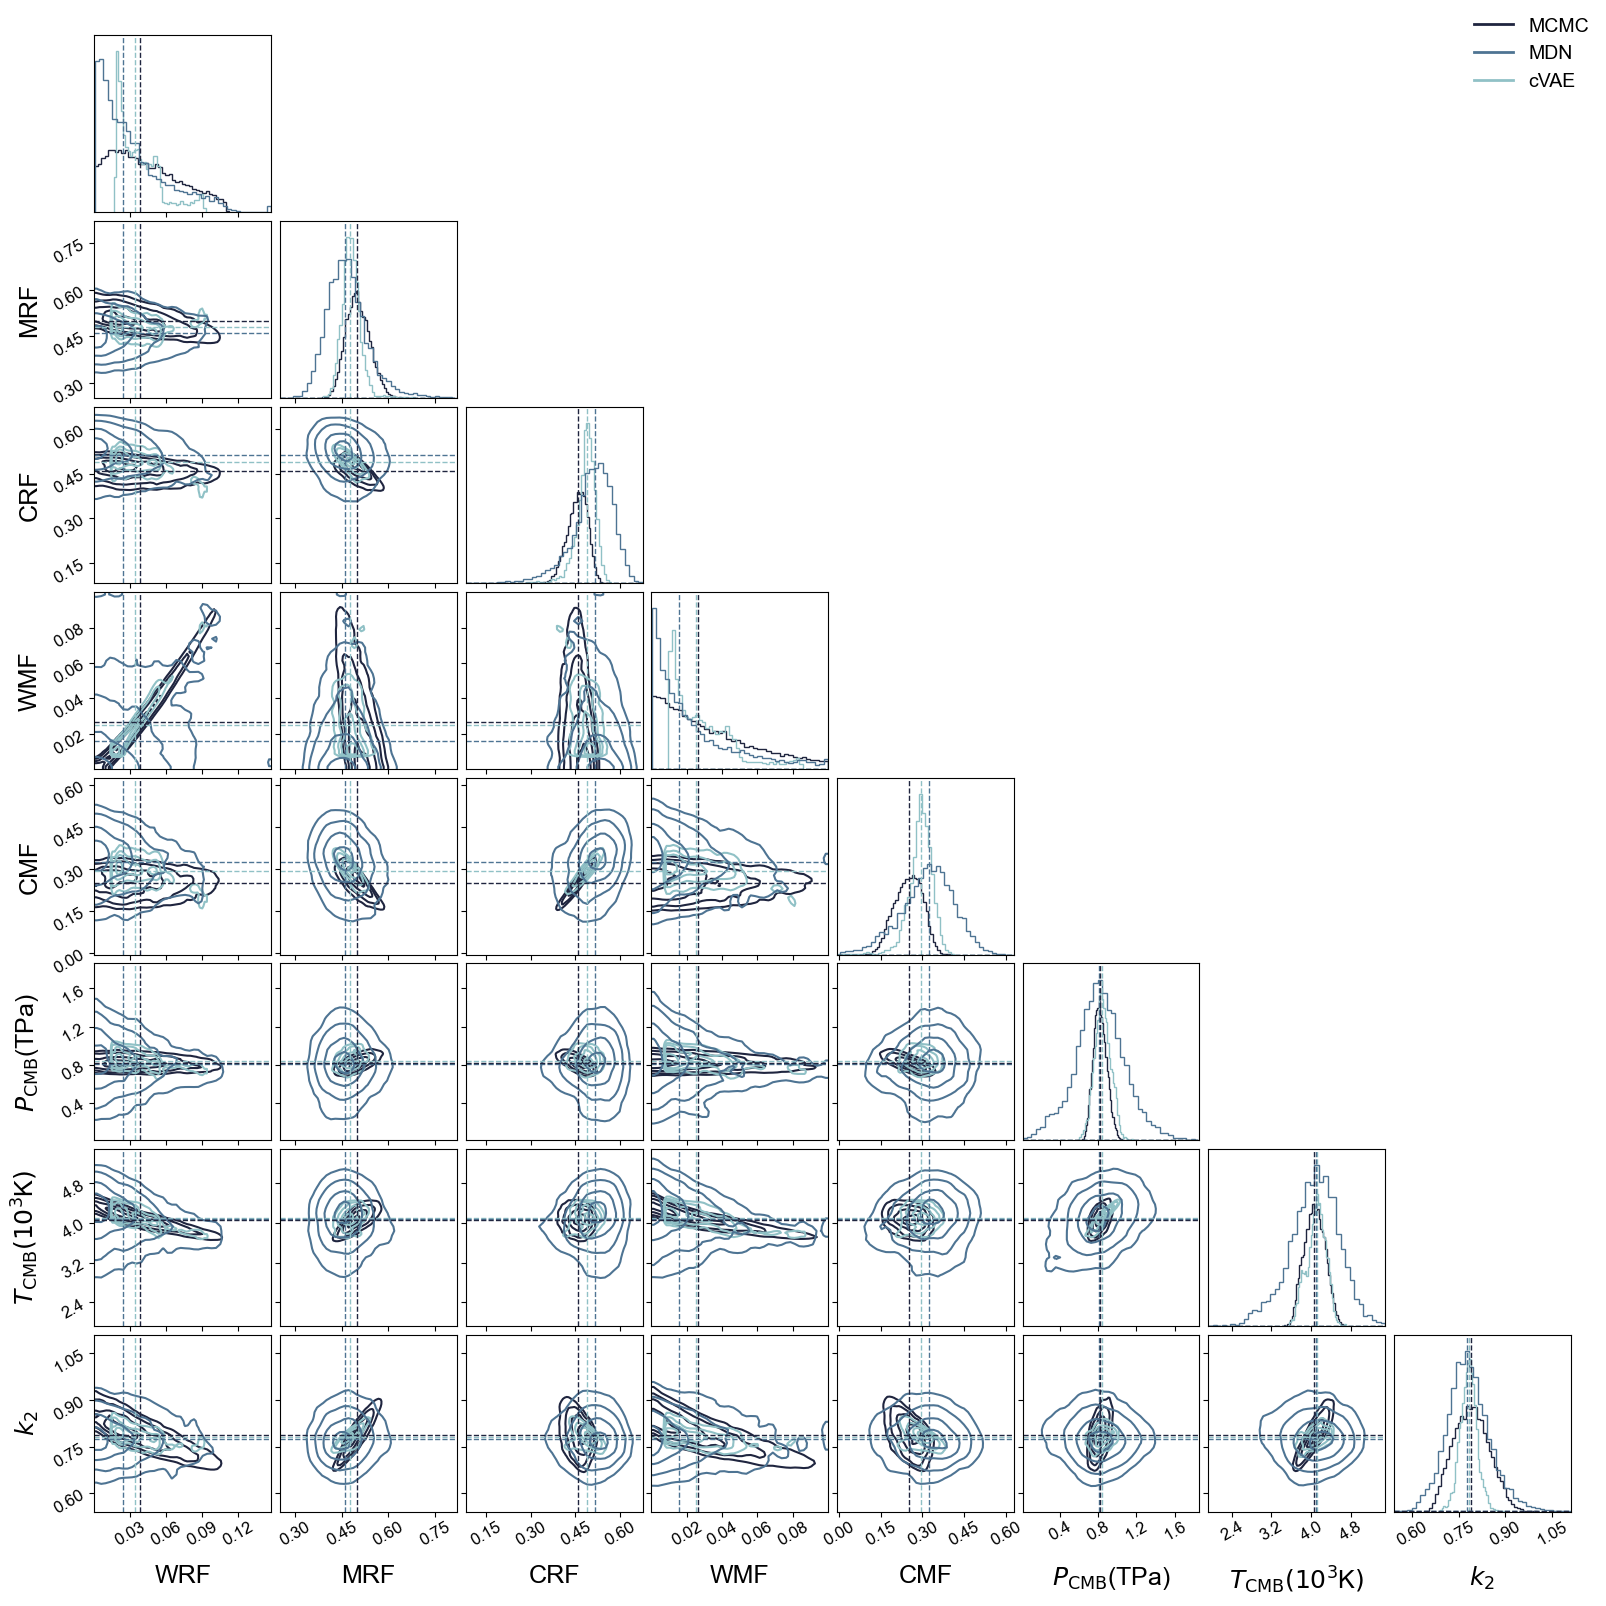

In [12]:
color_set = {
    "MCMC": '#1f253f',
    "MDN": '#4e7493',
    "cVAE": "#90c1c6"
}

fig = plt.figure(figsize=(16, 16))
corner.corner(
    mcmc_df_sub,
    color=color_set['MCMC'],
    labels=x_labels,
    bins=40,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    show_titles=False,
    fig=fig,
    spacing=0.02
)

corner.corner(
    cvae_df_sub,
    color=color_set['cVAE'],
    labels=x_labels,
    bins=40,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    show_titles=False,
    fig=fig,
    spacing=0.02
)

corner.corner(
    mdn_df_sub,
    color=color_set['MDN'],
    labels=x_labels,
    bins=40,
    smooth=1.0,
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    show_titles=False,
    fig=fig,
    spacing=0
)
axes = fig.axes

count = 0
for i in range(0, len(axes), 8):
    
    ax = axes[i]
    for k in range(count + 1):
        ax_sub = axes[i + k]
        for spine in ax_sub.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_color('black')
        
        if i == len(axes) - 8:
            ax_sub.set_xlabel(x_labels[k], fontsize=18)
            ax_sub.tick_params(axis='x', which='both', top=False, bottom=True, direction='out', labelsize=12, pad=2, rotation=30)
        
        cvae_vmedian = cvae_df_sub.iloc[:, k].median()
        mdn_vmedian = mdn_df_sub.iloc[:, k].median()
        mcmc_vmedian = mcmc_df_sub.iloc[:, k].median()
        
        ax_sub.axvline(cvae_vmedian, linestyle='--', color=color_set['cVAE'], lw=1)
        ax_sub.axvline(mdn_vmedian, linestyle='--', color=color_set['MDN'], lw=1)
        ax_sub.axvline(mcmc_vmedian, linestyle='--', color=color_set['MCMC'], lw=1)
        
        if count >= 1:
            cvae_hmedian = cvae_df_sub.iloc[:, count].median()
            mdn_hmedian = mdn_df_sub.iloc[:, count].median()
            mcmc_hmedian = mcmc_df_sub.iloc[:, count].median()
            
            ax_sub.axhline(cvae_hmedian, linestyle='--', color=color_set['cVAE'], lw=1)
            ax_sub.axhline(mdn_hmedian, linestyle='--', color=color_set['MDN'], lw=1)
            ax_sub.axhline(mcmc_hmedian, linestyle='--', color=color_set['MCMC'], lw=1)

    if i > 0:
        ax.set_ylabel(x_labels[count], fontsize=18)
        ax.tick_params(axis='y', which='both', left=True, right=False, direction='out', labelsize=12, pad=2, rotation=30)
    
    
    
    count += 1

handles = [
    mlines.Line2D([], [], color='#1f253f', lw=2, label='MCMC'),
    mlines.Line2D([], [], color='#4e7493', lw=2, label='MDN'),
    mlines.Line2D([], [], color='#90c1c6', lw=2, label='cVAE')
]

fig.legend(handles=handles,
           loc='upper right',
           frameon=False,
           fontsize=14)
# plt.tight_layout()
plt.show()
# fig.savefig(os.path.join(corner_plot_path, "corner_{}.pdf".format(planet_name)), dpi=300, bbox_inches='tight', transparent=True)

In [17]:
# df_for_cornor = model_comparison['Kepler78b']
# df_for_cornor.iloc[:, :-1] = df_for_cornor.iloc[:, :-1].astype(float)

cvae_df.to_csv(os.path.join(corner_plot_path, "cVAE_prediction.csv"))
mdn_df.to_csv(os.path.join(corner_plot_path, "MDN_prediction.csv"))

In [18]:
axes = fig.axes

In [19]:
axes = fig.axes


In [20]:
cvae_df_sub.iloc[:, 0].median()

0.046494663